# QF 627 Programming and Computational Finance
## Problem Set `4` | `Questions`

19:54

> "Hi Team! 👋

> The current notebook contains 8 questions that help you review our course content.

> Each question asks you to answer with specific results. Some questions are the `reverse-engineering-type` questions as I have asked in exercise problem set 3. Other questions require direct answers (because, given the nature of the question, reverse-engineering is not feasible).

> These questions won’t be difficult to solve—and working through them will strengthen your understanding of the learning materials. This week’s questions ask you to preview the lecture note script for Lesson 4, which we will continue in Lesson 5, and then attempt to answer the exercises.

> This preview exercise will help you consolidate the upcoming lessons more effectively. Once you have completed it, please submit your script via eLearn.

> Enjoy!"

##### First, let's do some quick exercise with stock prices data.

### <font color = green> Activation of necessary libraries. </font>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

from pandas_datareader import data as pdr

import datetime as dt
import yfinance as yf

> Let's set some print option.

In [2]:
np.set_printoptions(precision = 3)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

In [3]:
from lets_plot import *
LetsPlot.setup_html()

### <font color = red> Question 1</font>. Please import historical stock data from the web on the following financial instruments, and create the following DataFrame that contains adjusted closing prices. 

### Here, the timeframe should be set between the 13th of October 2014 through the 13th of September 2022 (nine years of data).

- `WMT` Stock of Walmart
- `IBM` Stock of IBM

In [4]:
df =\
yf.download(['WMT', 'IBM'], 
            auto_adjust = False,
            start = '2014-10-13',
            end = '2022-09-14')['Adj Close']

[*********************100%***********************]  2 of 2 completed


In [5]:
df.head()

Ticker,IBM,WMT
Date,,
2014-10-13,110.969681,20.890909
2014-10-14,111.138947,21.004045
2014-10-15,109.899391,20.255247
2014-10-16,108.744492,19.883547
2014-10-17,110.080795,19.958954


### <font color = red> Question 2</font>. Please run a simple moving average crossover strategy for `IBM`.

### The two moving windows are 20 and 60 days.

### Please show your positions with a plot.

### <mark> What is shown below is a sample to illustrate the type of visualization you should display; the results you obtain may not necessarily be the same.</mark>

In [6]:
ibm = df[['IBM']]
ibm['SMA_20'] = ibm['IBM'].rolling(window = 20).mean()
ibm['SMA_60'] = ibm['IBM'].rolling(window = 60).mean()
ibm

Ticker,IBM,SMA_20,SMA_60
Date,,,
2014-10-13,110.969681,NaN,NaN
2014-10-14,111.138947,NaN,NaN
2014-10-15,109.899391,NaN,NaN
2014-10-16,108.744492,NaN,NaN
2014-10-17,110.080795,NaN,NaN
...,...,...,...
2022-09-07,113.740067,118.133904,118.805319
2022-09-08,114.416939,117.998976,118.731712
2022-09-09,115.058167,117.849799,118.659850


In [7]:
ibm['Signal'] =\
(
    np.where(
        ibm['SMA_20'] > ibm['SMA_60'],1,-1
    )
)
ibm

Ticker,IBM,SMA_20,SMA_60,Signal
Date,,,,
2014-10-13,110.969681,NaN,NaN,-1
2014-10-14,111.138947,NaN,NaN,-1
2014-10-15,109.899391,NaN,NaN,-1
2014-10-16,108.744492,NaN,NaN,-1
2014-10-17,110.080795,NaN,NaN,-1
...,...,...,...,...
2022-09-07,113.740067,118.133904,118.805319,-1
2022-09-08,114.416939,117.998976,118.731712,-1
2022-09-09,115.058167,117.849799,118.659850,-1


In [8]:
ibm['trade'] = ibm['Signal'].diff()
ibm

Ticker,IBM,SMA_20,SMA_60,Signal,trade
Date,,,,,
2014-10-13,110.969681,NaN,NaN,-1,NaN
2014-10-14,111.138947,NaN,NaN,-1,0.0
2014-10-15,109.899391,NaN,NaN,-1,0.0
2014-10-16,108.744492,NaN,NaN,-1,0.0
2014-10-17,110.080795,NaN,NaN,-1,0.0
...,...,...,...,...,...
2022-09-07,113.740067,118.133904,118.805319,-1,0.0
2022-09-08,114.416939,117.998976,118.731712,-1,0.0
2022-09-09,115.058167,117.849799,118.659850,-1,0.0


In [9]:
ibm.trade.value_counts()

trade
 0.0    1959
 2.0      17
-2.0      17
Name: count, dtype: int64

In [10]:
ibm.shape

(1994, 5)

In [11]:
ibm = ibm.dropna()
ibm.shape

(1935, 5)

<Axes: xlabel='Date'>

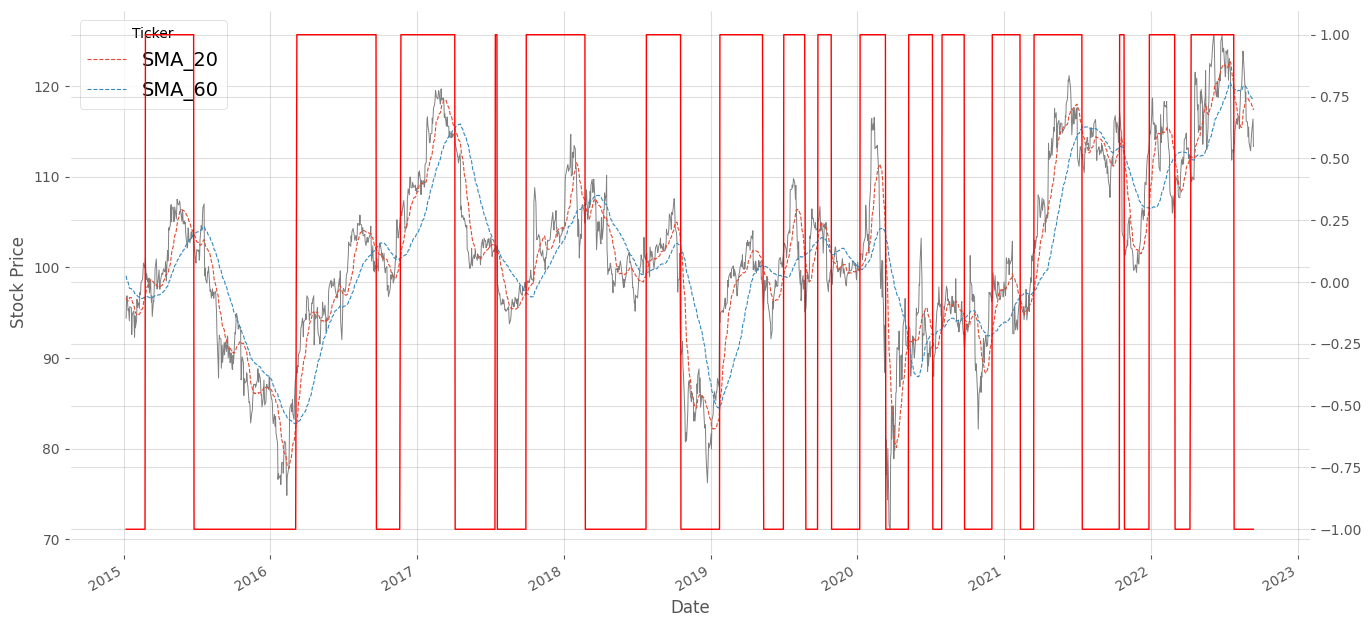

In [12]:
f =\
(
    plt
    .figure(figsize = [16,8]
           )
)

sub=\
(
    f
    .add_subplot(111,
                 ylabel = "Stock Price")
)

# Price Action (Daily)

(
    ibm
    ["IBM"]
    .plot(ax = sub,
          lw = 0.70,
          color = "grey")
)

# Moving Averages(Shorter vs. Longer)

(
    ibm
    [["SMA_20", "SMA_60"]]
    .plot(ax = sub,
          lw = 0.80,
          style = ["--", "--"]
         )
)

# plot signals
sub2 = sub.twinx()

(
    ibm['Signal']
    .plot(ax= sub2,
          lw = 1,
          style = ["-"],
          color = "red"
    )
)


### <font color = red> Question 3</font>. Based on your lines of codes that lead to answer 2 above, compare the returns to see if the strategy leads to a win over the passive benchmark investment.

In [13]:
ibm

Ticker,IBM,SMA_20,SMA_60,Signal,trade
Date,,,,,
2015-01-07,94.396294,96.620590,99.068452,-1,0.0
2015-01-08,96.447990,96.481476,98.826424,-1,0.0
2015-01-09,96.868073,96.438860,98.588576,-1,0.0
2015-01-12,95.242516,96.297919,98.344295,-1,0.0
2015-01-13,95.467789,96.341449,98.123016,-1,0.0
...,...,...,...,...,...
2022-09-07,113.740067,118.133904,118.805319,-1,0.0
2022-09-08,114.416939,117.998976,118.731712,-1,0.0
2022-09-09,115.058167,117.849799,118.659850,-1,0.0


In [14]:
ibm['passive_return'] =\
np.log(
    ibm['IBM'] / ibm['IBM'].shift(1)
)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_53649/94920452.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ibm['passive_return'] =\


In [15]:
ibm

Ticker,IBM,SMA_20,SMA_60,Signal,trade,passive_return
Date,,,,,,
2015-01-07,94.396294,96.620590,99.068452,-1,0.0,NaN
2015-01-08,96.447990,96.481476,98.826424,-1,0.0,0.021502
2015-01-09,96.868073,96.438860,98.588576,-1,0.0,0.004346
2015-01-12,95.242516,96.297919,98.344295,-1,0.0,-0.016924
2015-01-13,95.467789,96.341449,98.123016,-1,0.0,0.002362
...,...,...,...,...,...,...
2022-09-07,113.740067,118.133904,118.805319,-1,0.0,0.007782
2022-09-08,114.416939,117.998976,118.731712,-1,0.0,0.005933
2022-09-09,115.058167,117.849799,118.659850,-1,0.0,0.005589


In [16]:
ibm['strategy_return'] =\
(
    ibm['passive_return'] * ibm['Signal'].shift(1)
)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_53649/3405249294.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ibm['strategy_return'] =\


In [17]:
ibm

Ticker,IBM,SMA_20,SMA_60,Signal,trade,passive_return,strategy_return
Date,,,,,,,
2015-01-07,94.396294,96.620590,99.068452,-1,0.0,NaN,NaN
2015-01-08,96.447990,96.481476,98.826424,-1,0.0,0.021502,-0.021502
2015-01-09,96.868073,96.438860,98.588576,-1,0.0,0.004346,-0.004346
2015-01-12,95.242516,96.297919,98.344295,-1,0.0,-0.016924,0.016924
2015-01-13,95.467789,96.341449,98.123016,-1,0.0,0.002362,-0.002362
...,...,...,...,...,...,...,...
2022-09-07,113.740067,118.133904,118.805319,-1,0.0,0.007782,-0.007782
2022-09-08,114.416939,117.998976,118.731712,-1,0.0,0.005933,-0.005933
2022-09-09,115.058167,117.849799,118.659850,-1,0.0,0.005589,-0.005589


<Axes: xlabel='Date'>

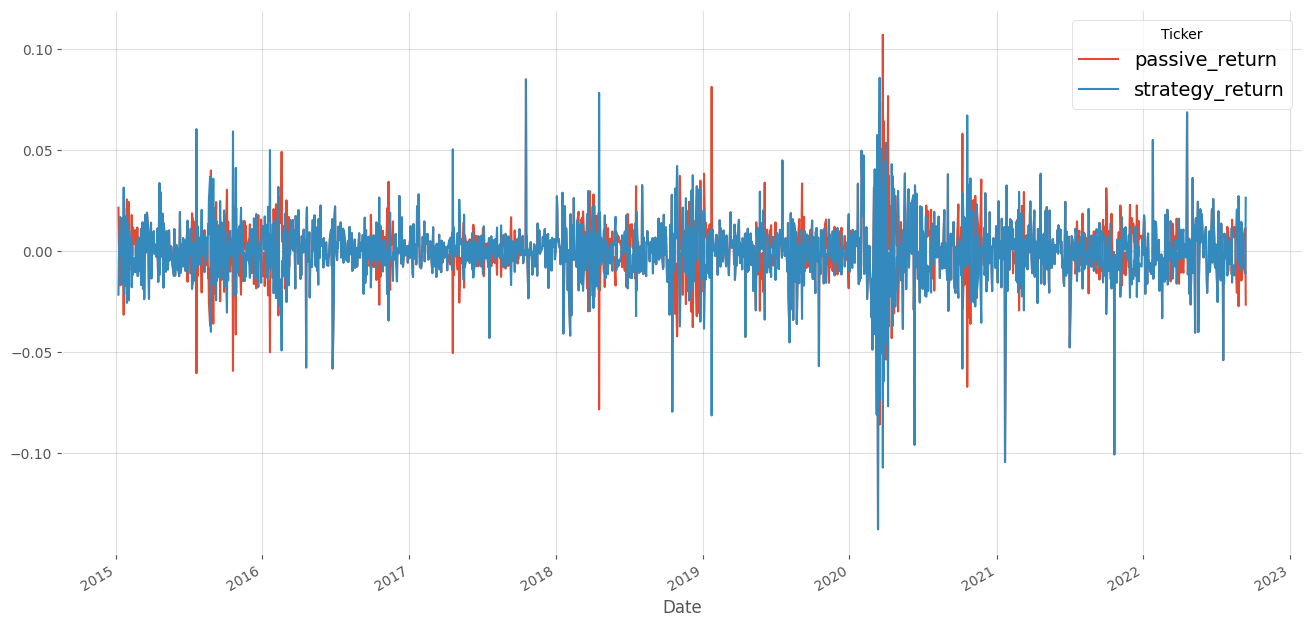

In [18]:
ibm[['passive_return','strategy_return']].plot(figsize = [16,8])

<Axes: xlabel='Date'>

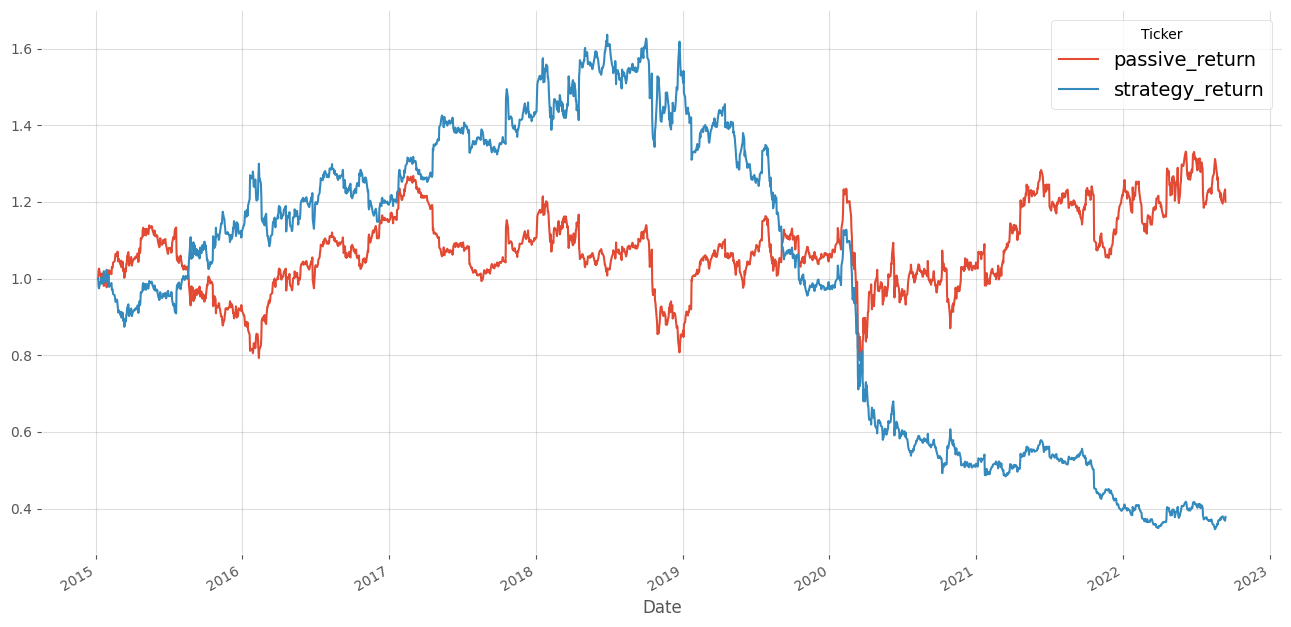

In [19]:
(
    ibm
    [["passive_return","strategy_return"]]
    .cumsum()
    .apply(np.exp)
).fillna(1).plot(figsize = [16,8])

### <font color = red> Question 4</font>. Based on your lines of codes that lead to answer 3 above, please calculate the maximum drawdown and the longest drawdown period.

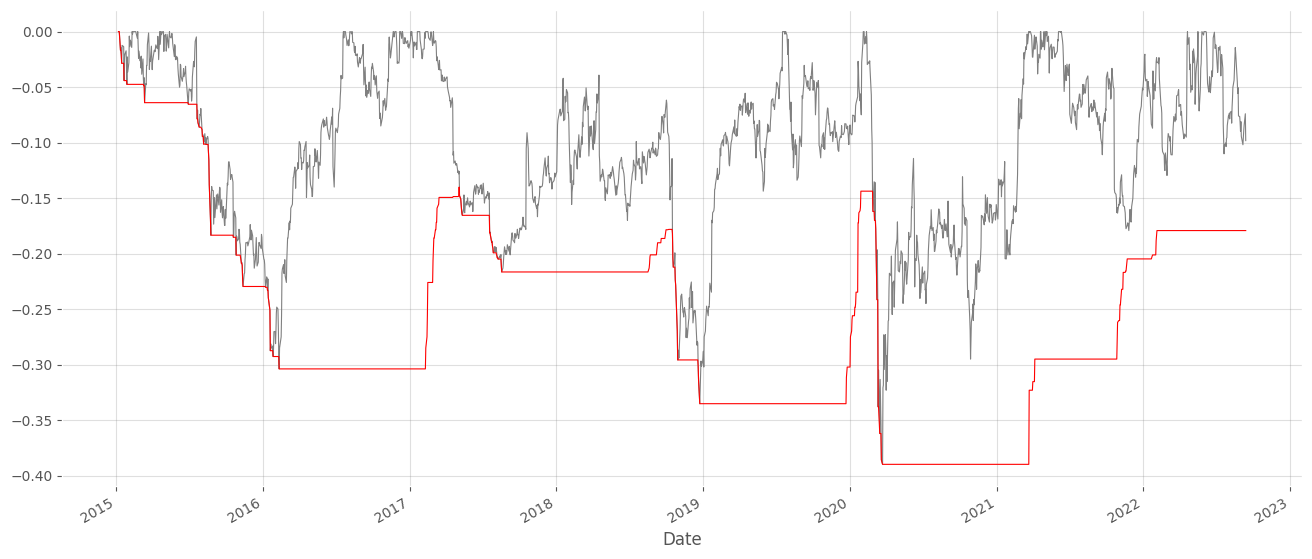

In [20]:
window = 252

rolling_max =\
(
    ibm
    ['IBM']
    .rolling(window = window,
             min_periods = 1)
    .max()
)

daily_drawdown =\
(
    (ibm['IBM'] / rolling_max) - 1.0
)

max_daily_drawdown =\
(
    daily_drawdown
    .rolling(window = window,
             min_periods = 1)
    .min()
)

fig = plt.figure(figsize = [16, 7]
                )

daily_drawdown.plot(color = "grey",
                    lw = 0.80)

max_daily_drawdown.plot(color = "red",
                        lw = 0.80)

plt.show()

In [21]:
ibm['cumulative_strategy_return'] =\
    ibm['strategy_return'].cumsum().apply(np.exp)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_53649/3836192872.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ibm['cumulative_strategy_return'] =\


In [22]:
ibm['max_gross_perf'] =\
(
    ibm['cumulative_strategy_return']
    .cummax()
)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_53649/3053191008.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ibm['max_gross_perf'] =\


<Axes: xlabel='Date'>

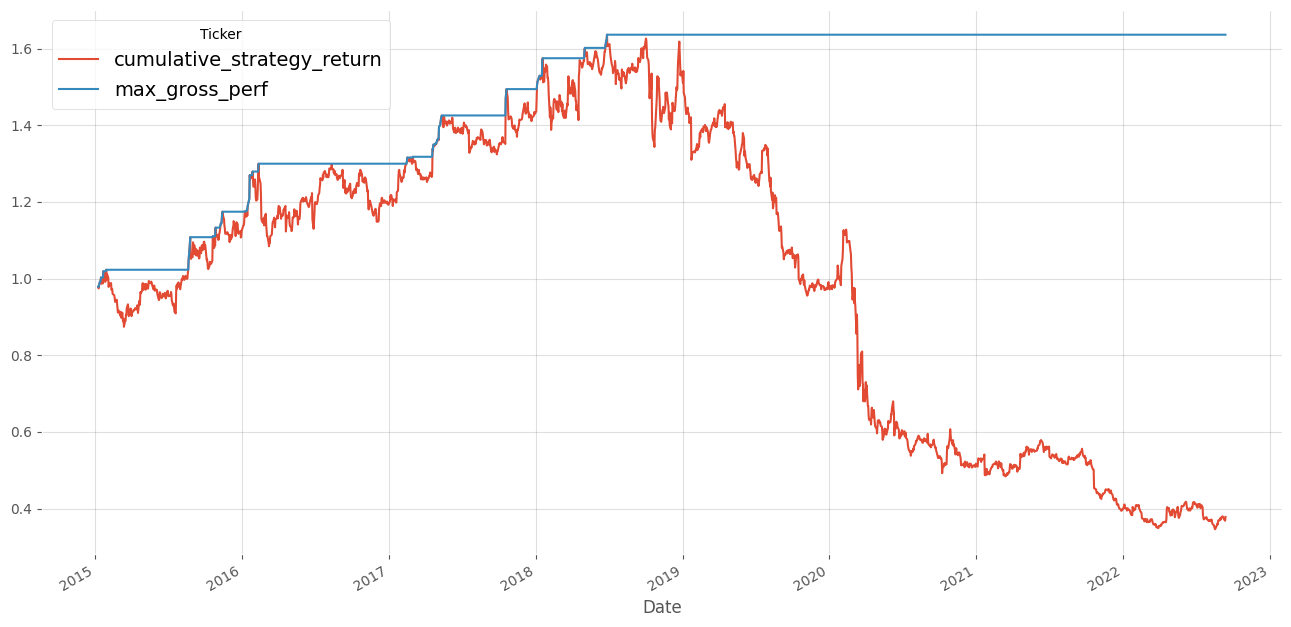

In [23]:
ibm[['cumulative_strategy_return','max_gross_perf']].plot(figsize = [16,8])

In [24]:
drawdown = (ibm['max_gross_perf'] - ibm['cumulative_strategy_return'])
max_drawdown = drawdown.max()

In [25]:
f"The maximum drawdown is about {max_drawdown*100:<.0f}% percentage points.",


('The maximum drawdown is about 129% percentage points.',)

In [26]:
periods =\
(
    drawdown[drawdown == 0.0].index[1:].to_pydatetime() - drawdown[drawdown == 0].shift(1).index[:-1].to_pydatetime()
    )

In [27]:
periods

array([datetime.timedelta(days=4), datetime.timedelta(days=2),
       datetime.timedelta(days=1), datetime.timedelta(days=6),
       datetime.timedelta(days=7), datetime.timedelta(days=204),
       datetime.timedelta(days=1), datetime.timedelta(days=3),
       datetime.timedelta(days=1), datetime.timedelta(days=56),
       datetime.timedelta(days=7), datetime.timedelta(days=13),
       datetime.timedelta(days=2), datetime.timedelta(days=1),
       datetime.timedelta(days=1), datetime.timedelta(days=56),
       datetime.timedelta(days=5), datetime.timedelta(days=2),
       datetime.timedelta(days=4), datetime.timedelta(days=1),
       datetime.timedelta(days=7), datetime.timedelta(days=15),
       datetime.timedelta(days=369), datetime.timedelta(days=1),
       datetime.timedelta(days=14), datetime.timedelta(days=49),
       datetime.timedelta(days=2), datetime.timedelta(days=5),
       datetime.timedelta(days=5), datetime.timedelta(days=2),
       datetime.timedelta(days=2), datetime.t

In [28]:
periods.max()

datetime.timedelta(days=369)

In [29]:
max_drawdown[max_drawdown == 0]

array([], dtype=float64)

In [30]:
ibm['max_gross_perf'].groupby(ibm['max_gross_perf']).count().sort_values(ascending = False).head(10)
# this method can miss out on calendar dates and only count trading days

max_gross_perf
1.636360    1061
1.299823     254
1.023095     142
1.425666     110
1.575000      72
1.494407      51
1.108118      39
1.174564      37
1.601973      36
1.317842      34
Name: max_gross_perf, dtype: int64

In [31]:
f"The longest drawdown period lasts for {periods.max()} days."

'The longest drawdown period lasts for 369 days, 0:00:00 days.'

### Please make sure to answer below.

    The maximum drawdown is about ___________ percentage points.
    The longest drawdown period lasts for ___________ days.

### <font color = red> Question 5</font>. Now let’s have a look at the stock price of Walmart (WMT). Please run a simple moving average crossover strategy.

### The two moving windows are 50 and 200 days.

### Now, please visualize your buy positions using red dots, and your sell positions using blue dots.

In [32]:
wmt = df[['WMT']]

In [33]:
wmt

Ticker,WMT
Date,
2014-10-13,20.890909
2014-10-14,21.004045
2014-10-15,20.255247
2014-10-16,19.883547
2014-10-17,19.958954
...,...
2022-09-07,43.546249
2022-09-08,43.767605
2022-09-09,43.899136


In [34]:
wmt.shape

(1994, 1)

In [35]:
short = 50
long = 200

wmt['sma_50'] = wmt['WMT'].rolling(window = short).mean()
wmt['sma_200'] = wmt['WMT'].rolling(window = long).mean()
wmt = wmt.dropna()

wmt.shape

(1795, 3)

In [36]:
wmt

Ticker,WMT,sma_50,sma_200
Date,,,
2015-07-29,19.805681,20.079335,21.794393
2015-07-30,19.786486,20.055918,21.788871
2015-07-31,19.737131,20.034420,21.782537
2015-08-03,19.791965,20.012868,21.780220
2015-08-04,19.811169,19.993070,21.779858
...,...,...,...
2022-09-07,43.546249,41.627556,43.840473
2022-09-08,43.767605,41.721171,43.834505
2022-09-09,43.899136,41.820292,43.825422


In [37]:
wmt['Signal'] =\
(
    np.where(
        wmt['sma_50'] > wmt['sma_200'],1,0
    )
)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_53649/2366705260.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wmt['Signal'] =\


In [38]:
wmt['trade'] = wmt['Signal'].diff()
wmt

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_53649/357474492.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wmt['trade'] = wmt['Signal'].diff()


Ticker,WMT,sma_50,sma_200,Signal,trade
Date,,,,,
2015-07-29,19.805681,20.079335,21.794393,0,NaN
2015-07-30,19.786486,20.055918,21.788871,0,0.0
2015-07-31,19.737131,20.034420,21.782537,0,0.0
2015-08-03,19.791965,20.012868,21.780220,0,0.0
2015-08-04,19.811169,19.993070,21.779858,0,0.0
...,...,...,...,...,...
2022-09-07,43.546249,41.627556,43.840473,0,0.0
2022-09-08,43.767605,41.721171,43.834505,0,0.0
2022-09-09,43.899136,41.820292,43.825422,0,0.0


/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_53649/3798830303.py:40: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  .plot(wmt[wmt.trade == 1.0].index,


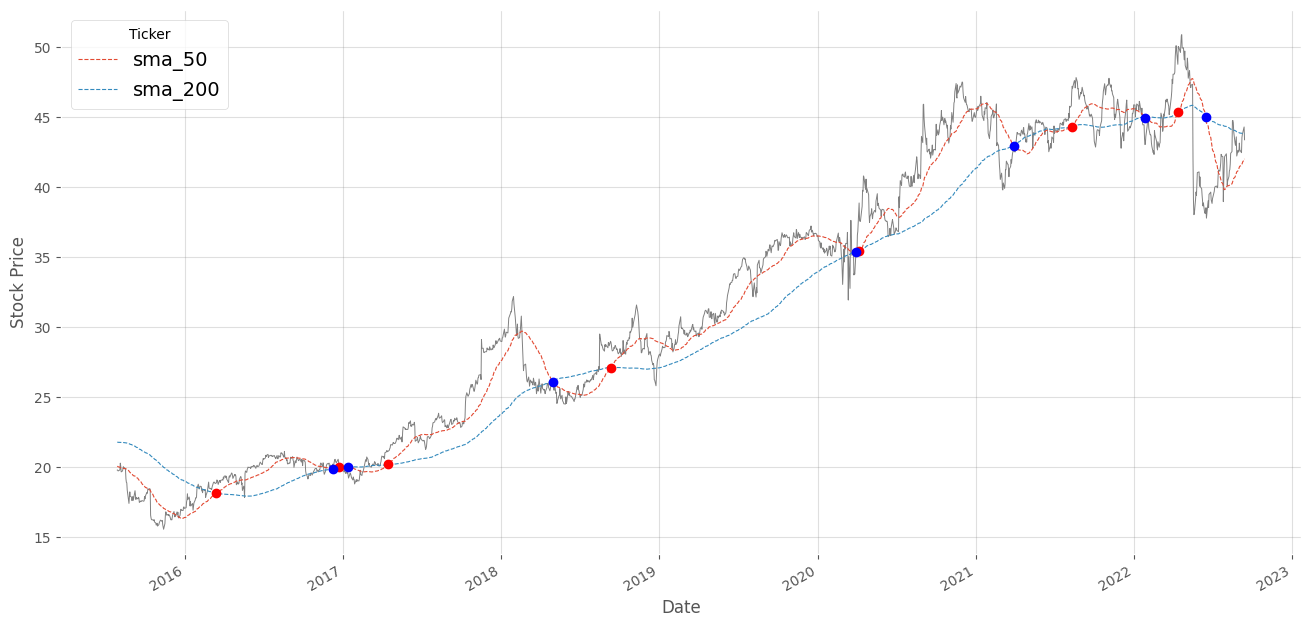

In [39]:
f =\
(
    plt
    .figure(figsize = [16,8]
           )
)

sub=\
(
    f
    .add_subplot(111,
                 ylabel = "Stock Price")
)

# Price Action (Daily)

(
    wmt
    ["WMT"]
    .plot(ax = sub,
          lw = 0.70,
          color = "grey")
)

# Moving Averages(Shorter vs. Longer)

(
    wmt
    [["sma_50", "sma_200"]]
    .plot(ax = sub,
          lw = 0.80,
          style = ["--", "--"]
         )
)

# BUY Signal

(
    sub
    .plot(wmt[wmt.trade == 1.0].index,
          wmt.sma_50[wmt.trade == 1.0],
          ".",
          color = "red",
          markersize = 12)
)

# SELL Signal

(
    sub
    .plot(wmt[wmt.trade == -1.0].index,
          wmt.sma_50[wmt.trade == -1.0],
          ".",
          color = "blue",
          markersize = 12)
)

In [40]:
total_trades = len((np.where(wmt['trade'] != 0))[0][1:])

In [41]:
f"Based on simple moving average crossover strategy, there were {total_trades} trading opportunities found."

'Based on simple moving average crossover strategy, there were 14 trading opportunities found.'

### Then, please come up with an answer for the question below.

    Based on simple moving average crossover strategy, there were _______ trading opportunities found.

### <font color = red> Question 6</font> Please draw the strategy returns as shown below.

### <mark> What is shown below is a sample to illustrate the type of visualization you should display; the results you obtain may not necessarily be the same.</mark>

In [42]:
wmt['passive_return'] =\
(
    np.log(
        wmt['WMT'] / wmt['WMT'].shift(1)
    )
)

wmt['passive_cum_return'] = wmt['passive_return'].cumsum().apply(np.exp)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_53649/2083119190.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wmt['passive_return'] =\
/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_53649/2083119190.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wmt['passive_cum_return'] = wmt['passive_return'].cumsum().apply(np.exp)


In [43]:
wmt['strategy_return'] =\
(
    wmt['passive_return'] * wmt['Signal'].shift(1)
)

wmt['strategy_cum_return'] = wmt['strategy_return'].cumsum().apply(np.exp)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_53649/2012140226.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wmt['strategy_return'] =\
/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_53649/2012140226.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wmt['strategy_cum_return'] = wmt['strategy_return'].cumsum().apply(np.exp)


<Axes: xlabel='Date'>

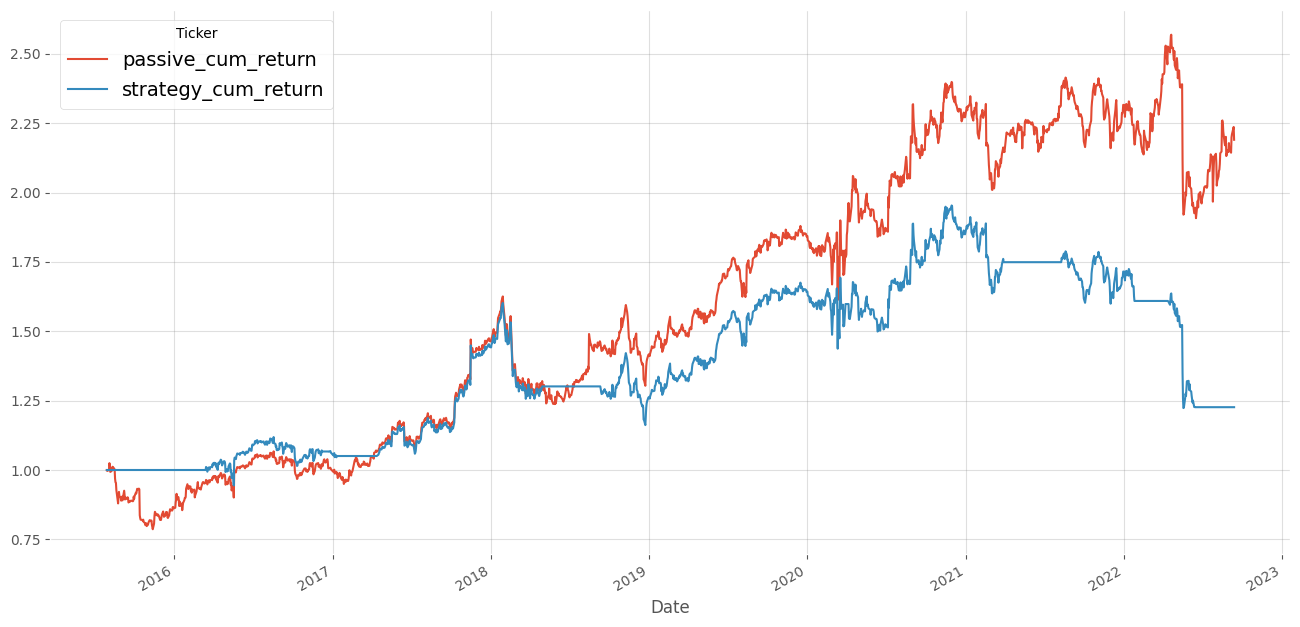

In [44]:
wmt[['passive_cum_return', 'strategy_cum_return']].plot(figsize = [16,8])

### <font color = red> Question 7</font>. Please calculate the Sharpe Ratio of the strategies for `IBM` and `WMT`, respectively.

    Simple moving strategy for IBM leads to a Sharpe ratio of _________ . 

    Simple moving strategy for WMT leads to a Sharpe ratio of _________ . 

In [45]:
wmt

Ticker,WMT,sma_50,sma_200,Signal,trade,passive_return,passive_cum_return,strategy_return,strategy_cum_return
Date,,,,,,,,,
2015-07-29,19.805681,20.079335,21.794393,0,NaN,NaN,NaN,NaN,NaN
2015-07-30,19.786486,20.055918,21.788871,0,0.0,-0.000970,0.999031,-0.0,1.000000
2015-07-31,19.737131,20.034420,21.782537,0,0.0,-0.002497,0.996539,-0.0,1.000000
2015-08-03,19.791965,20.012868,21.780220,0,0.0,0.002774,0.999307,0.0,1.000000
2015-08-04,19.811169,19.993070,21.779858,0,0.0,0.000970,1.000277,0.0,1.000000
...,...,...,...,...,...,...,...,...,...
2022-09-07,43.546249,41.627556,43.840473,0,0.0,0.025367,2.198675,0.0,1.226397
2022-09-08,43.767605,41.721171,43.834505,0,0.0,0.005070,2.209851,0.0,1.226397
2022-09-09,43.899136,41.820292,43.825422,0,0.0,0.003001,2.216492,0.0,1.226397


In [46]:
ibm['strategy_return'].mean() / ibm['passive_return'].std() * np.sqrt(252)

np.float64(-0.510387384035866)

In [47]:
wmt['strategy_return'].mean() / wmt['passive_return'].std() * np.sqrt(252)

np.float64(0.12766498541585553)

In [48]:
wmt['strategy_return'].mean()


np.float64(0.00011375738335649987)

### <font color = red> Question 8</font>. Please calculate the Compound Annual Growth Rate (CAGR) of the strategies for `IBM` and `WMT`, respectively.

    Simple moving strategy for IBM leads to a CAGR of _________ .

    Simple moving strategy for WMT leads to a CAGR of _________ .


In [49]:
days =\
(
    ibm.index[-1] - ibm.index[0]
).days

In [ ]:
ibm_cagr = (ibm.iloc[-1]['cumulative_strategy_return']/1)**(252/days) - 1
wmt_cagr = (wmt.iloc[-1]['strategy_cum_return']/1)**(252/days) - 1

In [54]:
f"Simple moving strategy for IBM leads to a CAGR of {ibm_cagr*100:.2f} %."


'Simple moving strategy for IBM leads to a CAGR of -12.72 %.'

In [55]:
f"Simple moving strategy for WMT leads to a CAGR of {wmt_cagr*100:.2f}%."

'Simple moving strategy for WMT leads to a CAGR of 2.90%.'

### <font color="green">"Thank you for putting your efforts into the exercise problem sets 💯"</font>